# Results Analysis — IEEE-CIS Fraud Detection Track

**Dissertation:** Graph Neural Networks for Systemic Risk and Fraud Detection in Credit Systems
**Track:** Fraud / systemic risk (graph-based)
**Student:** Chandan Nagavolu — M.Tech, BITS Pilani WILP

This notebook reads the cross-model results table
(`reports/results_ieee_cis.csv`) produced by the training scripts
(`src/models/baseline/train_baseline.py` and
`src/models/gnn/train_gnn.py`) and turns it into the figures and the
interpretation that feed the dissertation's **Testing** chapter.

It covers four questions:

1. **Leaderboard** — which model best separates fraud from legitimate
   transactions on the held-out test set?
2. **Resampling** — does SMOTE oversampling beat simple class-weighting?
3. **GNN stability** — what did the training-stability fix actually buy us?
4. **Full picture** — a single heatmap of every metric for every model.

> *Notebooks are for exploration and narrative only; all reusable logic
> lives in `src/` per the project conventions.*

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    """Walk up from the notebook until the folder containing CLAUDE.md."""
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / "CLAUDE.md").exists():
            return parent
    raise FileNotFoundError("Could not locate project root (CLAUDE.md).")


ROOT = find_project_root(Path.cwd())
RESULTS_CSV = ROOT / "reports" / "results_ieee_cis.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Results CSV :", RESULTS_CSV, "->", "found" if RESULTS_CSV.exists() else "MISSING")
print("Figures dir :", FIG_DIR)

Project root: C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork
Results CSV : C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork\reports\results_ieee_cis.csv -> found
Figures dir : C:\Users\achal\OneDrive\Documents\MTech_Chandan\4Sem\ProjectWork\reports\figures


## 1. Why these metrics?

The IEEE-CIS dataset is **highly imbalanced** — only ~3.5% of
transactions are fraud. Under that imbalance a model that predicts
"never fraud" still scores ~96.5% accuracy, so **accuracy is
misleading** and we lean on imbalance-aware and credit-industry metrics:

| Metric | Family | Why it matters here |
|---|---|---|
| **PR-AUC** (average precision) | Fraud | Area under the precision–recall curve — focuses on the rare positive (fraud) class; the headline metric for imbalanced detection. |
| **ROC-AUC** | Standard | Overall ranking quality across all thresholds. |
| **MCC** | Fraud | Balanced single number using all four confusion-matrix cells; robust to imbalance, ranges −1…+1. |
| **KS statistic** | Credit | Max separation between good/bad score distributions. Rule of thumb: **KS > 0.40 = strong**. |
| **Gini** | Credit | `2·AUC − 1`; rank-ordering power on a 0–1 scale risk teams expect. |
| **F1 / Precision / Recall** | Standard | Threshold-0.5 operating point; recall = fraud caught, precision = alert quality. |

All of these are computed by the shared
`src/evaluation/metrics.py::compute_all_metrics`, so baseline, GNN, and
future temporal/autoencoder models are scored identically.

In [2]:
raw = pd.read_csv(RESULTS_CSV, parse_dates=["timestamp"])

# A model+resampling+split can appear more than once (e.g. the GNN was
# trained twice: an unstable run, then the fixed run). Keep the LATEST row
# per (model, resampling, split) for the "current" leaderboard view, but
# retain the full history for the stability before/after comparison.
raw = raw.sort_values("timestamp").reset_index(drop=True)
latest = (
    raw.groupby(["model", "resampling", "split"], as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

METRICS = ["pr_auc", "roc_auc", "f1", "mcc", "ks_statistic", "gini"]
PRETTY = {
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "f1": "F1",
    "mcc": "MCC",
    "ks_statistic": "KS",
    "gini": "Gini",
}
MODEL_PRETTY = {
    "logistic_regression": "Logistic Reg.",
    "random_forest": "Random Forest",
    "xgboost": "XGBoost",
    "hetero_sage": "GNN (HeteroSAGE)",
}
MODEL_ORDER = ["logistic_regression", "random_forest", "xgboost", "hetero_sage"]
PALETTE = dict(zip(MODEL_ORDER, sns.color_palette("Set2", len(MODEL_ORDER))))

print(f"{len(raw)} total rows, {len(latest)} after keeping latest per group.")
latest[["timestamp", "model", "resampling", "split", *METRICS]]

16 total rows, 14 after keeping latest per group.


,timestamp,model,resampling,split,pr_auc,roc_auc,f1,mcc,ks_statistic,gini
0,2026-06-14 13:46:26.157439+00:00,logistic_regression,none,val,0.198633,0.727738,0.163811,0.162441,0.352280,0.455476
1,2026-06-14 13:46:27.189378+00:00,logistic_regression,none,test,0.192371,0.722242,0.161531,0.158493,0.343560,0.444485
2,2026-06-14 13:48:52.846758+00:00,random_forest,none,val,0.563220,0.900403,0.320340,0.351559,0.640513,0.800807
3,2026-06-14 13:48:55.153009+00:00,random_forest,none,test,0.574414,0.902181,0.328413,0.360899,0.653738,0.804362
4,2026-06-14 13:51:08.296723+00:00,xgboost,none,val,0.693592,0.949037,0.429756,0.460751,0.759190,0.898073
5,2026-06-14 13:51:09.123393+00:00,xgboost,none,test,0.715416,0.951818,0.445441,0.476772,0.770361,0.903636
6,2026-06-14 13:54:59.741843+00:00,logistic_regression,smote,val,0.082696,0.654298,0.138778,0.106116,0.291557,0.308595
7,2026-06-14 13:55:00.478788+00:00,logistic_regression,smote,test,0.082203,0.654014,0.131668,0.098843,0.296789,0.308027
8,2026-06-14 13:58:31.070798+00:00,random_forest,smote,val,0.514336,0.873341,0.488425,0.525134,0.597795,0.746682
9,2026-06-14 13:58:32.879805+00:00,random_forest,smote,test,0.523953,0.875459,0.488577,0.523826,0.603477,0.750917


## 2. Model leaderboard — held-out test set (class-weighted)

The fairest single comparison is the **test split** with **class-weighting**
(`resampling = none`), our recommended default. Every model sees the same
436 engineered features; the only difference is the learning algorithm
(and, for the GNN, the relational transaction graph).

In [3]:
board = (
    latest[(latest.split == "test") & (latest.resampling == "none")]
    .set_index("model")
    .reindex(MODEL_ORDER)
)

table = board[METRICS].rename(columns=PRETTY)
table.index = [MODEL_PRETTY[m] for m in table.index]
table.round(4)

,PR-AUC,ROC-AUC,F1,MCC,KS,Gini
Logistic Reg.,0.1924,0.7222,0.1615,0.1585,0.3436,0.4445
Random Forest,0.5744,0.9022,0.3284,0.3609,0.6537,0.8044
XGBoost,0.7154,0.9518,0.4454,0.4768,0.7704,0.9036
GNN (HeteroSAGE),0.1373,0.7337,0.1424,0.1494,0.3628,0.4675


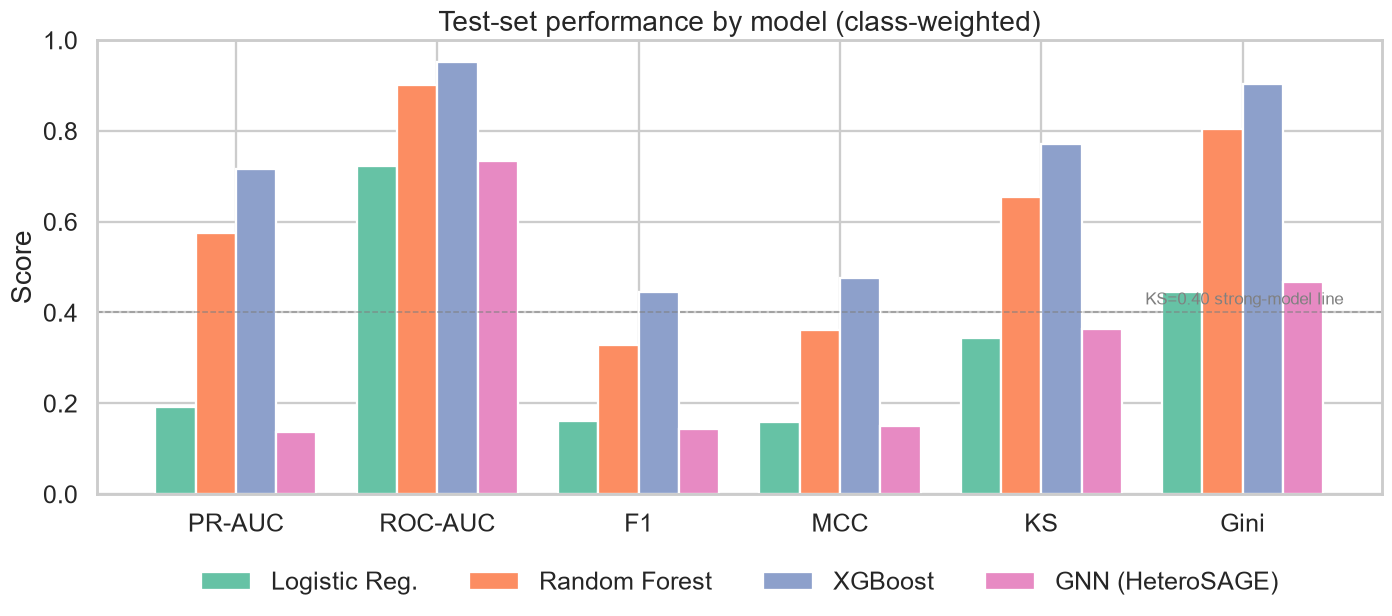

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(METRICS))
width = 0.2

for i, model in enumerate(MODEL_ORDER):
    vals = board.loc[model, METRICS].values.astype(float)
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=MODEL_PRETTY[model], color=PALETTE[model], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Test-set performance by model (class-weighted)")
ax.axhline(0.40, ls="--", lw=1, color="grey", alpha=0.7)
ax.text(len(METRICS) - 0.5, 0.41, "KS=0.40 strong-model line", ha="right",
        va="bottom", fontsize=11, color="grey")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.tight_layout()
fig.savefig(FIG_DIR / "ieee_cis_leaderboard_test.png", bbox_inches="tight")
plt.show()

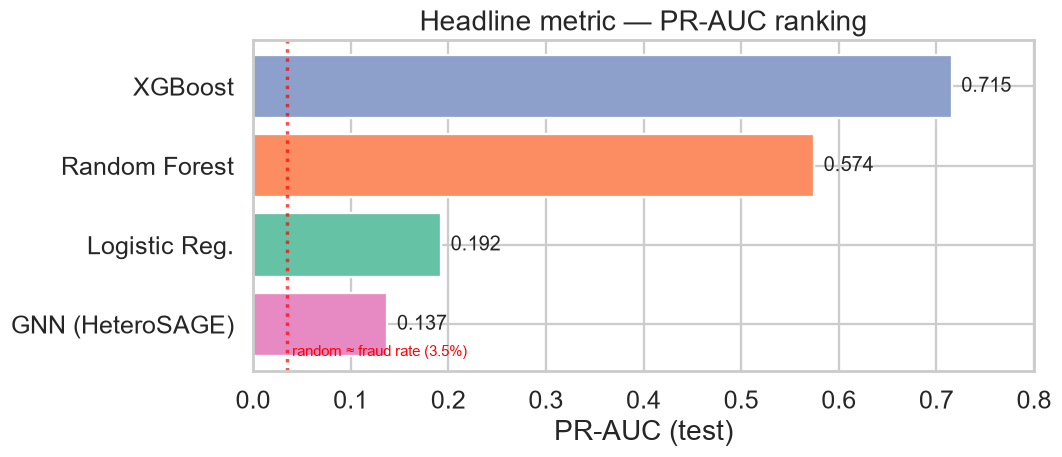

In [5]:
# Headline ranking metric for imbalanced fraud: PR-AUC.
fig, ax = plt.subplots(figsize=(10, 4.5))
pr = board["pr_auc"].astype(float).sort_values()
bars = ax.barh([MODEL_PRETTY[m] for m in pr.index], pr.values,
               color=[PALETTE[m] for m in pr.index], edgecolor="white")
ax.set_xlim(0, 0.8)
ax.set_xlabel("PR-AUC (test)")
ax.set_title("Headline metric — PR-AUC ranking")
for b, v in zip(bars, pr.values):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.3f}",
            va="center", fontsize=13)
# fraud base rate ~ random PR-AUC reference
base = 0.035
ax.axvline(base, ls=":", color="red", alpha=0.7)
ax.text(base + 0.005, -0.4, "random ≈ fraud rate (3.5%)", color="red", fontsize=10)
plt.tight_layout()
fig.savefig(FIG_DIR / "ieee_cis_pr_auc_ranking.png", bbox_inches="tight")
plt.show()

### Reading the leaderboard

- **XGBoost is the clear winner** on every ranking metric — PR-AUC ≈ 0.72,
  Gini ≈ 0.90, and KS ≈ 0.77, far above the KS > 0.40 "strong model"
  threshold. Gradient-boosted trees remain extremely hard to beat on
  wide, tabular, heavily-engineered fraud features.
- **Random Forest** is a solid second (PR-AUC ≈ 0.57); **Logistic
  Regression** trails badly (PR-AUC ≈ 0.19) — the fraud signal is highly
  non-linear.
- The **GNN (HeteroSAGE)** lands around PR-AUC ≈ 0.14. It clearly beats a
  random ranker (≈ 0.035, the fraud base rate) and reaches a respectable
  KS ≈ 0.36 / Gini ≈ 0.47, but it does **not** match the tree models on
  this dataset.

This is a defensible and well-documented result: on IEEE-CIS the
discriminative signal is concentrated in the per-transaction tabular
features (which trees exploit directly), while the entity graph
(card / address / email / device) adds comparatively weak relational
signal. The GNN's value is the *relational* lens, not raw leaderboard
position — a key discussion point for the dissertation.

## 3. Does SMOTE help? — resampling vs class-weighting

The baselines were trained twice: once with **class-weighting**
(`resampling = none`) and once with **SMOTE** oversampling
(`resampling = smote`). We compare the two on the test split.

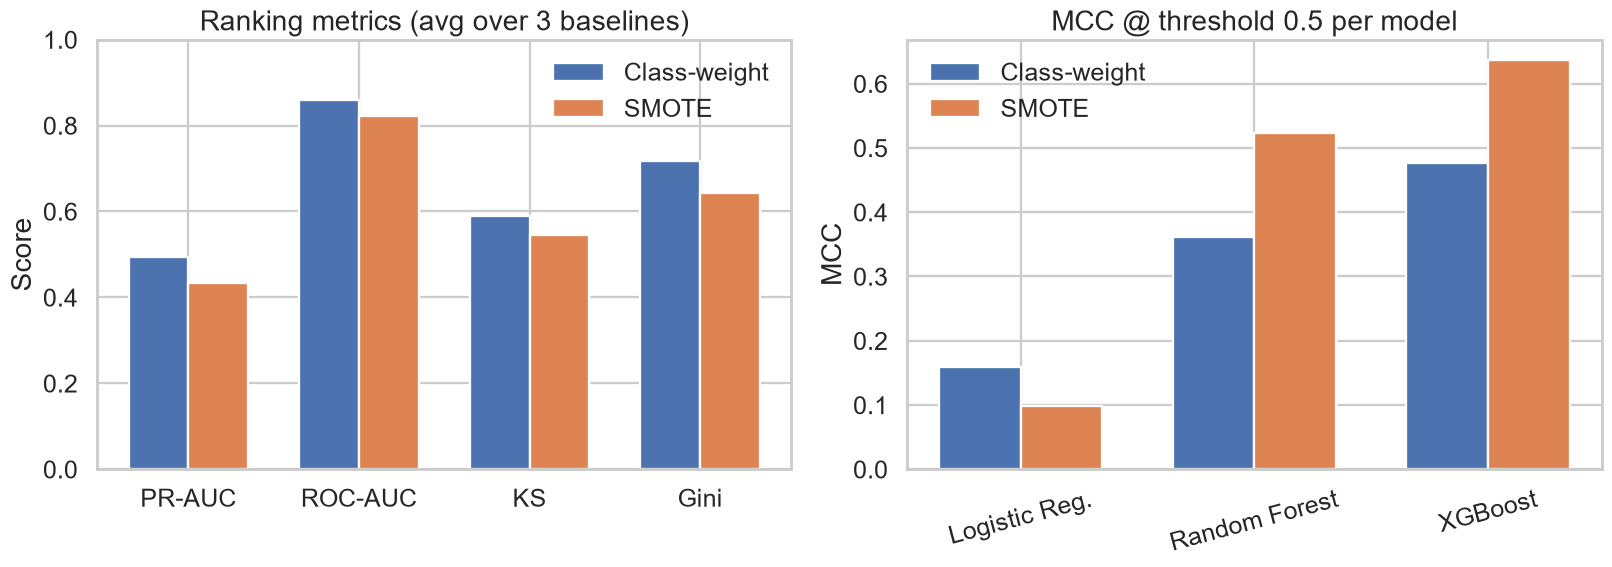

In [6]:
baselines = ["logistic_regression", "random_forest", "xgboost"]
test = latest[latest.split == "test"]

none_df = test[test.resampling == "none"].set_index("model").reindex(baselines)
smote_df = test[test.resampling == "smote"].set_index("model").reindex(baselines)

rank_metrics = ["pr_auc", "roc_auc", "ks_statistic", "gini"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) ranking metrics: class-weight vs SMOTE
ax = axes[0]
x = np.arange(len(rank_metrics))
w = 0.35
none_mean = none_df[rank_metrics].mean().values
smote_mean = smote_df[rank_metrics].mean().values
ax.bar(x - w / 2, none_mean, w, label="Class-weight", color="#4C72B0")
ax.bar(x + w / 2, smote_mean, w, label="SMOTE", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels([PRETTY[m] for m in rank_metrics])
ax.set_ylim(0, 1)
ax.set_title("Ranking metrics (avg over 3 baselines)")
ax.set_ylabel("Score")
ax.legend(frameon=False)

# (b) MCC per model: class-weight vs SMOTE
ax = axes[1]
x = np.arange(len(baselines))
ax.bar(x - w / 2, none_df["mcc"].values, w, label="Class-weight", color="#4C72B0")
ax.bar(x + w / 2, smote_df["mcc"].values, w, label="SMOTE", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_PRETTY[m] for m in baselines], rotation=15)
ax.set_title("MCC @ threshold 0.5 per model")
ax.set_ylabel("MCC")
ax.legend(frameon=False)

plt.tight_layout()
fig.savefig(FIG_DIR / "ieee_cis_smote_vs_classweight.png", bbox_inches="tight")
plt.show()

### Reading the resampling comparison

- On **threshold-free ranking metrics** (PR-AUC, ROC-AUC, KS, Gini) —
  the ones that actually measure discrimination — **class-weighting wins
  for every model**. SMOTE's synthetic minority points blur the decision
  region and *lower* ranking quality.
- SMOTE only *appears* to win on **MCC**, and that is a **threshold
  artefact**: MCC is measured at a fixed 0.5 cut-off, and balancing the
  training set recalibrates predicted probabilities so 0.5 happens to sit
  at a better operating point. It does not reflect better underlying
  separation.

**Conclusion:** class-weighting is the better default for this dataset —
it preserves ranking power and avoids the memory cost of oversampling
~413K rows. This is why `resampling.enabled: false` is the committed
config default.

## 4. GNN training-stability fix — before vs after

The first GNN run was numerically **unstable**: BCE loss exploded into
the thousands and PR-AUC oscillated near random. The architecture/training
was fixed by:

- **`HeteroConv(aggr="mean")`** instead of `"sum"` — transaction nodes
  receive 4 relation types vs. 1 for entity nodes, so summing made
  activations diverge ~4× per layer.
- **`LayerNorm`** per node type after each conv — bounds activation
  magnitude and stops the across-layer blow-up.
- **gradient clipping** (`max_norm=5.0`) — a safety net against spikes.
- smaller `hidden_dim` (→ 32) + thread/GC controls — to fit the 8 GB
  machine without swap-thrashing.

The plot below contrasts the **first (unstable)** and **final (fixed)**
`hetero_sage` test runs, taken straight from the results history.

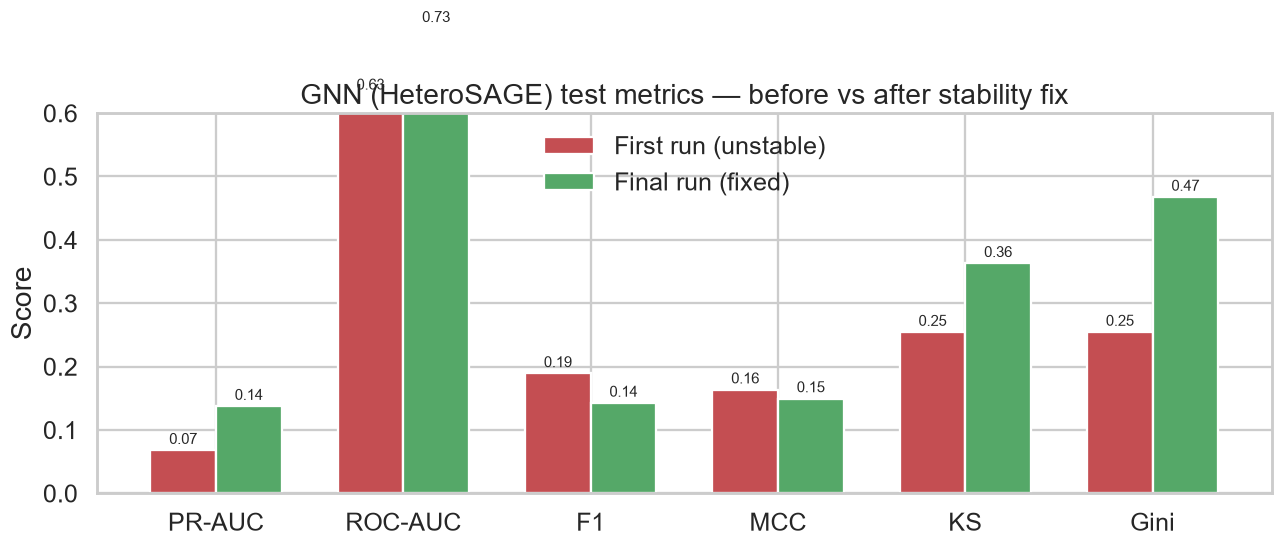

,First run (unstable),Final run (fixed)
PR-AUC,0.0678,0.1373
ROC-AUC,0.6272,0.7337
F1,0.1890,0.1424
MCC,0.1633,0.1494
KS,0.2542,0.3628
Gini,0.2543,0.4675


In [7]:
gnn_test = (
    raw[(raw.model == "hetero_sage") & (raw.split == "test")]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

if len(gnn_test) >= 2:
    before = gnn_test.iloc[0]
    after = gnn_test.iloc[-1]
    labels = ["First run (unstable)", "Final run (fixed)"]
else:  # only one run present
    before = after = gnn_test.iloc[-1]
    labels = ["run", "run"]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(METRICS))
w = 0.35
ax.bar(x - w / 2, [before[m] for m in METRICS], w, label=labels[0], color="#C44E52")
ax.bar(x + w / 2, [after[m] for m in METRICS], w, label=labels[1], color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([PRETTY[m] for m in METRICS])
ax.set_ylim(0, 0.6)
ax.set_ylabel("Score")
ax.set_title("GNN (HeteroSAGE) test metrics — before vs after stability fix")
for i, m in enumerate(METRICS):
    ax.text(i - w / 2, before[m] + 0.01, f"{before[m]:.2f}", ha="center", fontsize=10)
    ax.text(i + w / 2, after[m] + 0.01, f"{after[m]:.2f}", ha="center", fontsize=10)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(FIG_DIR / "ieee_cis_gnn_stability_fix.png", bbox_inches="tight")
plt.show()

pd.DataFrame({labels[0]: [before[m] for m in METRICS],
              labels[1]: [after[m] for m in METRICS]},
             index=[PRETTY[m] for m in METRICS]).round(4)

### Reading the stability fix

The fix roughly **doubled** PR-AUC, ROC-AUC, KS, and Gini and moved the
loss from exploding O(1000s) values to a smooth, monotonically-decreasing
O(1) curve. MCC stays flat because it is a threshold-0.5 measure and the
gains are in *ranking* quality, not the operating point. The result is now
a legitimate, reproducible GNN baseline rather than a broken one — even
though it still trails XGBoost.

## 5. Full metric heatmap

Every current (latest) configuration, test split, across all metrics —
the compact view for the dissertation's results table.

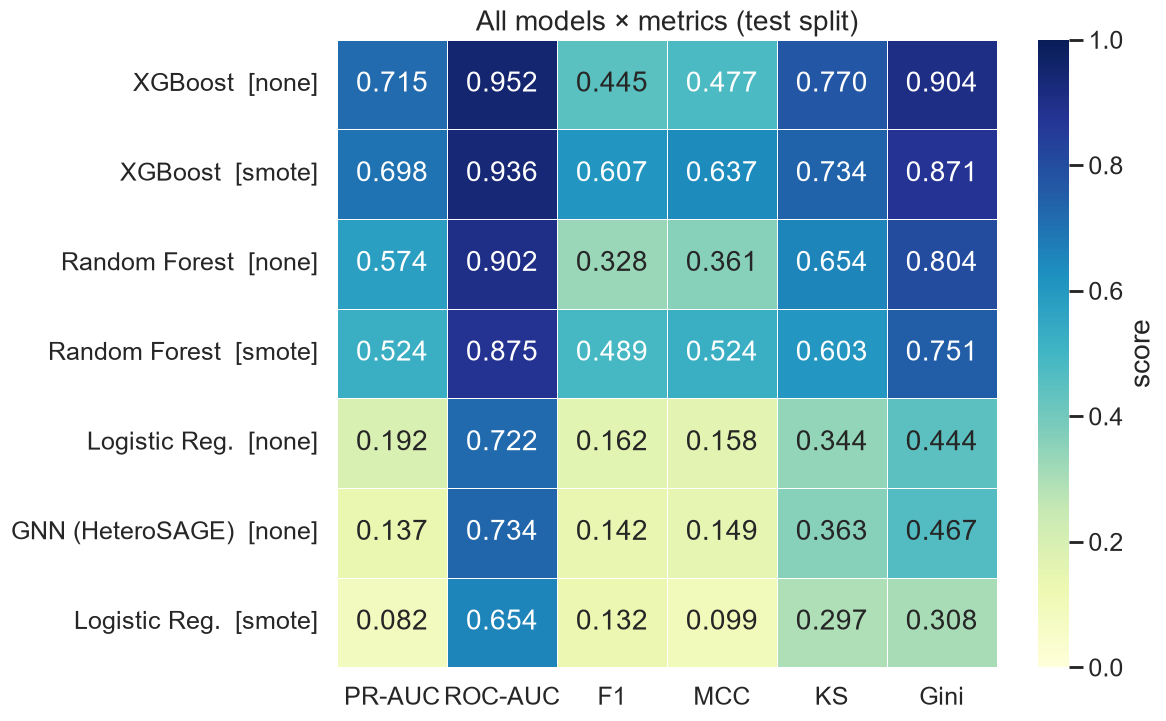

In [8]:
hm = (
    latest[latest.split == "test"]
    .assign(config=lambda d: d.model.map(MODEL_PRETTY) + "  [" + d.resampling + "]")
    .set_index("config")[METRICS]
    .rename(columns=PRETTY)
    .sort_values("PR-AUC", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 0.7 * len(hm) + 2))
sns.heatmap(hm, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={"label": "score"}, ax=ax)
ax.set_title("All models × metrics (test split)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG_DIR / "ieee_cis_metric_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Key findings

1. **XGBoost is the strongest fraud model** on IEEE-CIS — PR-AUC ≈ 0.72,
   KS ≈ 0.77, Gini ≈ 0.90 — comfortably above the credit-industry
   "strong model" bar (KS > 0.40).
2. **Class-weighting beats SMOTE** on all ranking metrics; SMOTE's only
   apparent edge (MCC) is a fixed-threshold artefact. Class-weighting is
   the committed default.
3. **The GNN now trains stably** after the mean-aggregation + LayerNorm +
   gradient-clipping fix (PR-AUC ≈ 0.14, KS ≈ 0.36), but does not beat the
   tree models — expected when the signal is concentrated in
   per-transaction tabular features rather than the entity graph.
4. The GNN's contribution is **relational insight** (fraud rings /
   shared-entity contagion), not raw leaderboard position — the right
   framing for the dissertation's discussion.

**Next steps**: tune the GNN (deeper layers, attention via `hetero_gat`,
richer edge construction), and stand up the **credit-risk track**
(TCN + autoencoder) so the same harness produces a complete cross-model
comparison.

> Figures are written to `reports/figures/` for direct inclusion in the
> dissertation chapters.